In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from scipy.fftpack import fft
from .utils import globals

In [29]:
orig = None
with open("../../Data/PHM2025_training_data/training_data.csv", "r") as f:
    orig = pd.read_csv(f)

train = orig.dropna().copy() #757 righe in meno

# Punti in cui avvengono le manutenzioni
def get_points(col, df=train):
    return df.loc[df[col] > df[col].shift(1), ["ESN", col]].copy()

wws = get_points('Cumulative_WWs')
hpc = get_points('Cumulative_HPC_SVs')
hpt = get_points('Cumulative_HPT_SVs')


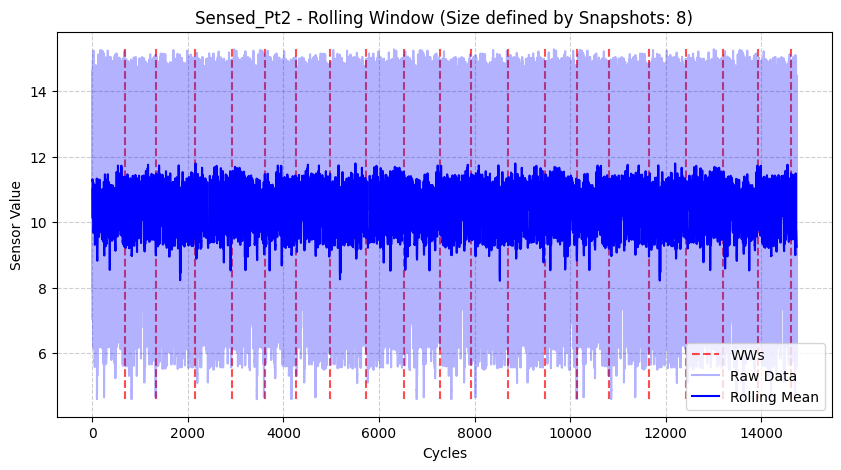

In [39]:
sensors = ["Sensed_Altitude", "Sensed_Mach", "Sensed_Pamb", "Sensed_Pt2", "Sensed_TAT", "Sensed_WFuel",
           "Sensed_VAFN", "Sensed_VBV", "Sensed_Fan_Speed", "Sensed_Core_Speed", "Sensed_T25",
           "Sensed_T3", "Sensed_Ps3", "Sensed_T45", "Sensed_P25", "Sensed_T5"]

ESN=101
sensor_name = "Sensed_Pt2"
roll = train.loc[train['ESN'] == int(ESN), [sensor_name, 'Snapshot']].copy()
wsize = 8
rolling_mean = roll[sensor_name].rolling(window=wsize).mean()

# Plotting
plt.figure(figsize=(10, 5))
plt.vlines(wws.loc[wws['ESN'] == ESN].index, ymin=roll[sensor_name].min(), ymax=roll[sensor_name].max(),
           colors='red', linestyles='dashed', label='WWs', alpha=0.7)
plt.plot(train.loc[train['ESN'] == int(ESN), [sensor_name]], label='Raw Data', color='blue', alpha=0.3)
plt.plot(rolling_mean, label='Rolling Mean', color='blue')
plt.title(f'{sensor_name} - Rolling Window (Size defined by Snapshots: {wsize})')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


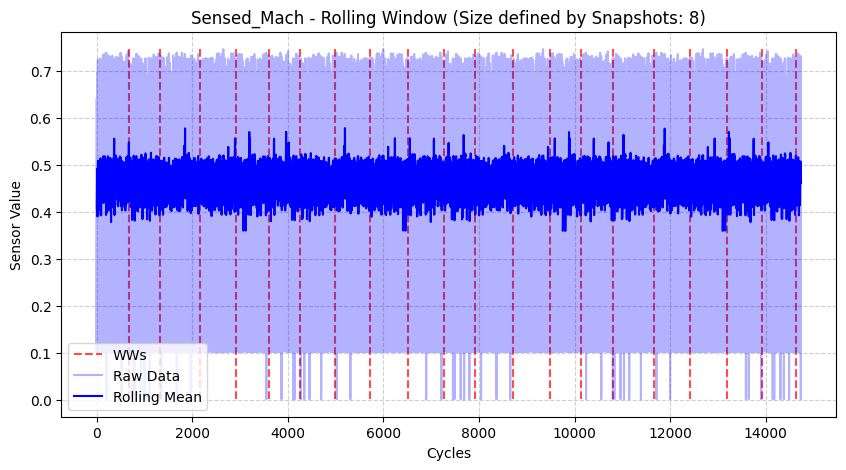

In [90]:
sensors = ["Sensed_Altitude", "Sensed_Mach", "Sensed_Pamb", "Sensed_Pt2", "Sensed_TAT", "Sensed_WFuel",
           "Sensed_VAFN", "Sensed_VBV", "Sensed_Fan_Speed", "Sensed_Core_Speed", "Sensed_T25",
           "Sensed_T3", "Sensed_Ps3", "Sensed_T45", "Sensed_P25", "Sensed_T5"]

ESN=101
sensor_name = "Sensed_Mach"
roll = train.loc[train['ESN'] == int(ESN), [sensor_name, 'Snapshot']].copy()
wsize = 8
rolling_mean = roll[sensor_name].rolling(window=wsize).mean()
raw = train.loc[train['ESN'] == int(ESN), [sensor_name]]


# Plotting
plt.figure(figsize=(10, 5))
plt.vlines(wws.loc[wws['ESN'] == ESN].index, ymin=roll[sensor_name].min(), ymax=roll[sensor_name].max(),
           colors='red', linestyles='dashed', label='WWs', alpha=0.7)
plt.plot(raw, label='Raw Data', color='blue', alpha=0.3)
plt.plot(rolling_mean, label='Rolling Mean', color='blue')
plt.title(f'{sensor_name} - Rolling Window (Size defined by Snapshots: {wsize})')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(f'ROLLING_{sensor_name}_ESN{ESN}.png')


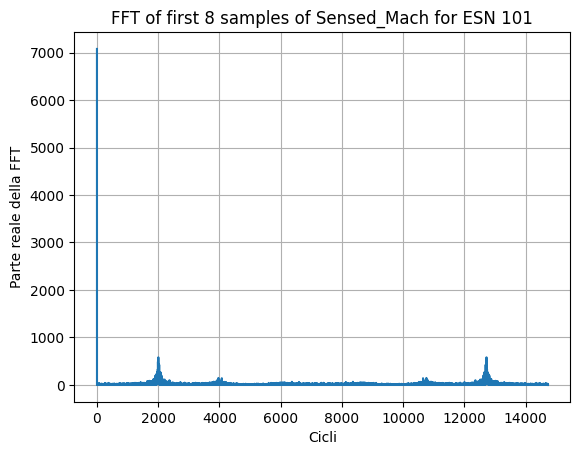

In [87]:
t = np.linspace(0, len(roll), len(roll), endpoint=False)
x = roll[sensor_name].values
yf = fft(x)
plt.plot(t, np.abs(yf))
plt.title(f'FFT of first 8 samples of {sensor_name} for ESN {ESN}')
plt.xlabel('Cicli')
plt.ylabel('Parte reale della FFT')
plt.grid()
plt.show()